In [4]:
%load_ext autoreload
%autoreload 2
# Importaciones necesarias
# !pip install -r ../requirements.txt
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# Imprimir versiones para diagnóstico
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")

# Asegurarse de que podemos importar desde el directorio raíz
sys.path.append("/Users/nacho/Desktop/code/PET_2025")

# Importar nuestras clases
from data.dataset import PETDataset
from utils.config_utils import load_config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
NumPy version: 1.26.4
PyTorch version: 2.2.2


In [5]:
# Cargar el CSV para explorarlo
csv_path = "/Volumes/Seagate/new_downloads/PET/PET_CoR_Dyn_6_04_2025.csv"
data_dir = "/Volumes/Seagate/new_downloads/PET/converted_niftis"

In [7]:
data = pd.read_csv(csv_path)
data

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I187071,002_S_2010,EMCI,F,63,bl,PET,Co-registered Dynamic,Processed,7/14/2010,DCM,5/29/2025
1,I193435,002_S_2043,EMCI,F,72,bl,PET,Co-registered Dynamic,Processed,9/15/2010,DCM,5/29/2025
2,I194760,002_S_2073,EMCI,F,64,bl,PET,Co-registered Dynamic,Processed,9/29/2010,DCM,5/29/2025
3,I257222,002_S_4171,LMCI,M,69,v03,PET,Co-registered Dynamic,Processed,9/02/2011,DCM,5/29/2025
4,I259150,002_S_4213,CN,F,78,v03,PET,Co-registered Dynamic,Processed,9/21/2011,DCM,5/29/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1111,I277275,941_S_4365,CN,M,80,v03,PET,Co-registered Dynamic,Processed,12/30/2011,DCM,5/29/2025
1112,I283681,941_S_4376,CN,F,77,v03,PET,Co-registered Dynamic,Processed,2/08/2012,DCM,5/29/2025
1113,I297527,941_S_4420,EMCI,M,82,v03,PET,Co-registered Dynamic,Processed,4/11/2012,DCM,5/29/2025
1114,I315156,941_S_4764,EMCI,F,83,v03,PET,Co-registered Dynamic,Processed,6/13/2012,DCM,5/29/2025


In [8]:
data.loc[data["Group"] == "EMCI", "Group"] = "MCI"
data.loc[data["Group"] == "LMCI", "Group"] = "MCI"
data.loc[data["Group"] == "SMC", "Group"] = "CN"

data["Group"] = data["Group"].astype("category")
data["Group"].value_counts()

Group
MCI    549
CN     341
AD     226
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

# seed 42
np.random.seed(42)
# set sklearn random state
from sklearn.utils import check_random_state

random_state = check_random_state(42)

# Dividir los datos en entrenamiento validación y test
# 80% entrenamiento, 10% validación, 10% test
train_data, test_data = train_test_split(
    data, test_size=0.4, random_state=42, stratify=data["Group"]
)
val_data, test_data = train_test_split(
    test_data, test_size=0.5, random_state=42, stratify=test_data["Group"]
)

# ouput:
#   train_csv: './data/metadata/adni_train.csv'
#   val_csv: './data/metadata/adni_val.csv'
#   test_csv: './data/metadata/adni_test.csv'

train_csv = Path("../data/metadata/adni_train_60.csv")
val_csv = Path("../data/metadata/adni_val_20.csv")
test_csv = Path("../data/metadata/adni_test_20.csv")

os.makedirs(train_csv.parent, exist_ok=True)

train_data.to_csv(train_csv, index=False)
val_data.to_csv(val_csv, index=False)
test_data.to_csv(test_csv, index=False)

# Prueba de PETDataset2D

En este notebook vamos a probar la clase `PETDataset2D` utilizando el archivo CSV: 
`/Volumes/Seagate/new_downloads/PETPET_CoR_Dyn_6_04_2025.csv`

Verificaremos:
1. La carga correcta de los datos
2. La visualización de algunas muestras
3. La distribución de las clases

## Stuff

In [ ]:
try:
    df = pd.read_csv(csv_path)
    print(f"CSV cargado correctamente. Forma: {df.shape}")
    print("\nPrimeras 5 filas:")
    display(df.head())

    print("\nColumnas disponibles:")
    print(df.columns.tolist())

    if "Group" in df.columns:
        print("\nDistribución de diagnósticos:")
        print(df["Group"].value_counts())
    elif "diagnosis" in df.columns:
        print("\nDistribución de diagnósticos:")
        print(df["diagnosis"].value_counts())
    else:
        print("\nNo se encontró columna de diagnóstico 'Group' o 'diagnosis'")
        # Intentar identificar la columna de diagnóstico
        for col in df.columns:
            unique_values = df[col].nunique()
            if unique_values <= 5:  # Asumimos que la columna de diagnóstico tiene pocas categorías
                print(f"Posible columna de diagnóstico '{col}': {df[col].value_counts()}")

    # Verificar si existe la columna Subject o path
    if "Subject" in df.columns:
        print("\nEjemplos de nombres de sujetos:")
        print(df["Subject"].head().tolist())
    elif "path" in df.columns:
        print("\nEjemplos de rutas:")
        print(df["path"].head().tolist())
    else:
        print("\nNo se encontró columna 'Subject' o 'path'")

except Exception as e:
    print(f"Error al cargar el CSV: {e}")

In [ ]:
# Verificar la estructura del directorio de datos
try:
    if os.path.exists(data_dir):
        print(f"El directorio de datos existe: {data_dir}")

        # Listar algunos archivos
        files = os.listdir(data_dir) if len(os.listdir(data_dir)) > 0 else []
        if not files:
            print("No se encontraron archivos en el directorio")

        # Buscar archivos .nii.gz
        nifti_files = []
        for root, _dirs, files in os.walk(data_dir):
            for file in files:
                if file.endswith(".nii.gz"):
                    nifti_files.append(os.path.join(root, file))

        if nifti_files:
            print(f"\nSe encontraron {len(nifti_files)} archivos .nii.gz:")
        else:
            print("\nNo se encontraron archivos .nii.gz en el directorio")
    else:
        print(f"El directorio de datos no existe: {data_dir}")
        print("Por favor, verifique la ruta y asegúrese de que el volumen esté montado.")

except Exception as e:
    print(f"Error al verificar directorio: {e}")

In [ ]:
# Crear una instancia de PETDataset2D mejorada para adaptarse a la estructura del CSV
class MejoradoPETDataset2D(PETDataset2D):
    def _load_dataset(self) -> None:
        """Carga información de las imágenes y prepara dataset."""
        print(f"Cargando dataset. Filas en CSV: {len(self.metadata)}")

        # Analizar columnas disponibles
        print(f"Columnas disponibles: {self.metadata.columns.tolist()}")

        # Determinar columnas a utilizar para identificación de sujeto y diagnóstico
        identificadores_sujeto = ["Subject", "path", "subject", "PTID", "ID", "filename"]
        identificadores_diagnostico = ["Group", "diagnosis", "DX", "group", "class", "label"]

        # Encontrar la columna de sujeto
        subject_col = next(
            (col for col in identificadores_sujeto if col in self.metadata.columns), None
        )
        if not subject_col:
            print("No se encontró una columna para identificar los sujetos.")
            # Buscar columnas con valores que parecen identificadores únicos
            for col in self.metadata.columns:
                if len(self.metadata[col].unique()) == len(self.metadata):
                    print(
                        f"Usando la columna '{col}' como identificador de sujetos (parece contener valores únicos)"
                    )
                    subject_col = col
                    break
            if not subject_col:
                raise ValueError("No se pudo determinar una columna para identificar sujetos")

        # Encontrar la columna de diagnóstico
        diagnosis_col = next(
            (col for col in identificadores_diagnostico if col in self.metadata.columns), None
        )
        if not diagnosis_col:
            print("No se encontró una columna que contenga diagnósticos.")
            # Buscar columnas con pocos valores únicos
            for col in self.metadata.columns:
                unique_vals = self.metadata[col].nunique()
                if 2 <= unique_vals <= 5:  # Típico para CN, MCI, AD, otros...
                    print(
                        f"Usando la columna '{col}' como diagnóstico (tiene {unique_vals} valores únicos)"
                    )
                    diagnosis_col = col
                    break
            if not diagnosis_col:
                raise ValueError("No se pudo determinar una columna para diagnósticos")

        print(f"Usando columna '{subject_col}' para identificar sujetos")
        print(f"Usando columna '{diagnosis_col}' para diagnósticos")
        print(
            f"Valores únicos en '{diagnosis_col}': {self.metadata[diagnosis_col].unique().tolist()}"
        )

        # Limitar a 10 sujetos para pruebas iniciales
        limit = 10
        count = 0

        # Mapeo de etiquetas
        self.etiquetas_unicas = self.metadata[diagnosis_col].unique()
        print(f"Etiquetas encontradas: {self.etiquetas_unicas}")

        for _idx, row in self.metadata.iterrows():
            if count >= limit:
                break

            # Determinar la ruta de la imagen según la estructura del proyecto
            subject_id = str(row[subject_col])

            # Intentar diferentes patrones comunes para localizar los archivos
            possible_paths = [
                # La ruta completa podría estar en la columna
                os.path.join(self.data_dir, subject_id)
                if not os.path.isabs(subject_id)
                else subject_id,
                # Nombre de archivo dentro del directorio principal
                os.path.join(self.data_dir, f"{subject_id}.nii.gz"),
                # Subdirectorio con nombre de sujeto que contiene archivo
                os.path.join(self.data_dir, subject_id, f"{subject_id}.nii.gz"),
                # Solo el nombre del sujeto sin extensión (buscar archivos)
                os.path.join(self.data_dir, subject_id),
            ]

            # Posibles sufijos de archivos si subject_id no incluye extensión
            possible_extensions = ["", ".nii", ".nii.gz", ".nifti"]

            # Ampliar lista de posibles rutas con diferentes extensiones
            extended_paths = []
            for path in possible_paths:
                if not path.endswith(tuple(possible_extensions)):
                    for ext in possible_extensions:
                        extended_paths.append(path + ext)
                else:
                    extended_paths.append(path)

            possible_paths = extended_paths

            # Buscar el archivo
            img_path = next((path for path in possible_paths if os.path.exists(path)), None)

            if img_path is None:
                print(
                    f"No se pudo encontrar archivo para sujeto {subject_id}. Se probaron las rutas:"
                )
                for p in possible_paths:
                    print(f"  - {p}")
                continue

            # Determinar la etiqueta
            try:
                label_value = row[diagnosis_col]

                # Manejar diferentes tipos de etiquetas
                if isinstance(label_value, str):
                    # Si es texto, convertir usando las funciones existentes
                    if label_value.upper() in ["CN", "CONTROL", "NORMAL", "HEALTHY", "HC"]:
                        label = 0
                    elif label_value.upper() in ["MCI", "EMCI", "LMCI"]:
                        label = 1
                    elif label_value.upper() in ["AD", "DEM", "DEMENTIA", "ALZHEIMER"]:
                        label = 2
                    else:
                        # Si no coincide con patrones conocidos, asignar número según posición
                        label_idx = list(self.etiquetas_unicas).index(label_value)
                        label = label_idx if label_idx < self.class_count else 0
                else:
                    # Si ya es numérico, usarlo directamente
                    label = int(label_value)

                    # Asegurarse de que está en rango
                    if label >= self.class_count:
                        print(
                            f"  ⚠️ Etiqueta {label} fuera de rango para {self.class_count} clases, ajustando a {label % self.class_count}"
                        )
                        label = label % self.class_count

            except Exception as e:
                print(f"Error al procesar etiqueta {row[diagnosis_col]}: {e}")
                continue

            print(f"Procesando imagen: {img_path}, etiqueta: {label}")

            # Cargar y procesar el volumen
            try:
                nifti = nib.load(img_path)
                img_data = nifti.get_fdata()
                print(f"  Forma del volumen: {img_data.shape}")

                # Seleccionar cortes según método elegido

                if self.slice_selection == "middle":
                    # Seleccionar slice central y los más cercanos según num_slices
                    middle_idx = img_data.shape[2] // 2
                    start = middle_idx - (self.num_slices // 2)
                    end = start + self.num_slices

                    # Asegurar que los índices están en rango
                    start = max(0, start)
                    end = min(img_data.shape[2], end)

                    slice_indices = list(range(start, end))

                elif self.slice_selection == "uniform":
                    # Seleccionar cortes espaciados uniformemente
                    slice_indices = np.linspace(
                        0, img_data.shape[2] - 1, self.num_slices, dtype=int
                    ).tolist()

                elif self.slice_selection == "all":
                    # Usar todos los cortes (limitar a max_slices para evitar problemas de memoria)
                    max_slices = min(img_data.shape[2], 20)  # Limitar a 20 cortes máximo
                    slice_indices = list(range(0, max_slices))

                else:
                    # Por defecto, usar el corte central
                    slice_indices = [img_data.shape[2] // 2]

                print(f"  Seleccionando {len(slice_indices)} cortes: {slice_indices}")

                # Procesar cada corte seleccionado
                for slice_idx in slice_indices:
                    if 0 <= slice_idx < img_data.shape[2]:
                        # Extraer y normalizar el corte
                        slice_data = img_data[:, :, slice_idx].copy()

                        # Normalizar (valores entre 0 y 1)
                        slice_min, slice_max = slice_data.min(), slice_data.max()
                        if slice_max > slice_min:
                            slice_data = (slice_data - slice_min) / (slice_max - slice_min)

                        # Añadir a la lista de muestras
                        self.samples.append((slice_data, label))
                        count += 1

                print(f"  ✓ {len(slice_indices)} cortes añadidos para sujeto {subject_id}")

            except Exception as e:
                print(f"  ✗ Error al procesar imagen {img_path}: {e}")

        print(f"Total de muestras cargadas: {len(self.samples)}")

        # Análisis de distribución de clases
        labels = [label for _, label in self.samples]
        unique_labels, counts = np.unique(labels, return_counts=True)

        print("\nDistribución de clases:")
        for label, count in zip(unique_labels, counts, strict=False):
            class_name = (
                "CN"
                if label == 0
                else "MCI"
                if label == 1
                else "AD"
                if label == 2
                else f"Clase {label}"
            )
            print(f"  - {class_name}: {count} muestras ({count / len(labels) * 100:.1f}%)")


dataset = MejoradoPETDataset2D(
    data_dir=data_dir,
    csv_path=csv_path,
    slice_selection="middle",  # Opciones: "middle", "uniform", "all"
    num_slices=3,  # Número de cortes a seleccionar
    mode="test",
)

print(f"\nDataset creado con {len(dataset)} muestras")

## Load Dataset

In [11]:
dataset = PETDataset(
    data_dir=data_dir,
    csv_path=csv_path,
    slice_selection="middle",  # Opciones: "middle", "uniform", "all"
    num_slices=16,  # Número de cortes a seleccionar
    mode="test",
    limit=40,  # Limitar a 10 sujetos para pruebas
)

print(f"\nDataset creado con {len(dataset)} muestras")

CSV cargado. Filas: 1116
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['EMCI', 'LMCI', 'CN', 'AD', 'SMC', 'MCI']


Cargando dataset:   0%|          | 1/1116 [00:00<08:54,  2.08it/s]

Cargado volumen de forma: (128, 128, 90, 6)


Cargando dataset:   3%|▎         | 35/1116 [00:37<19:30,  1.08s/it]



KeyboardInterrupt: 

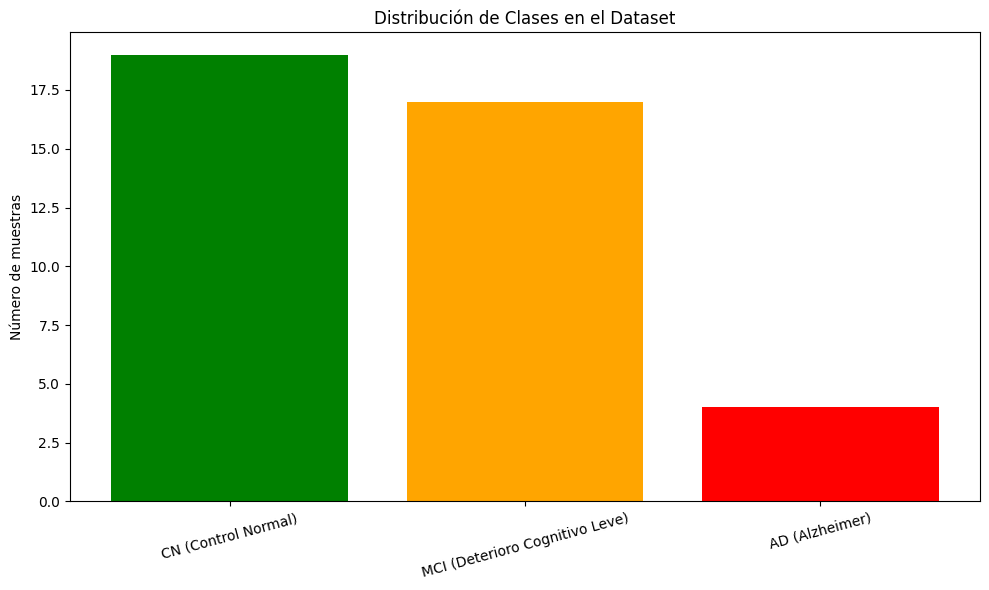

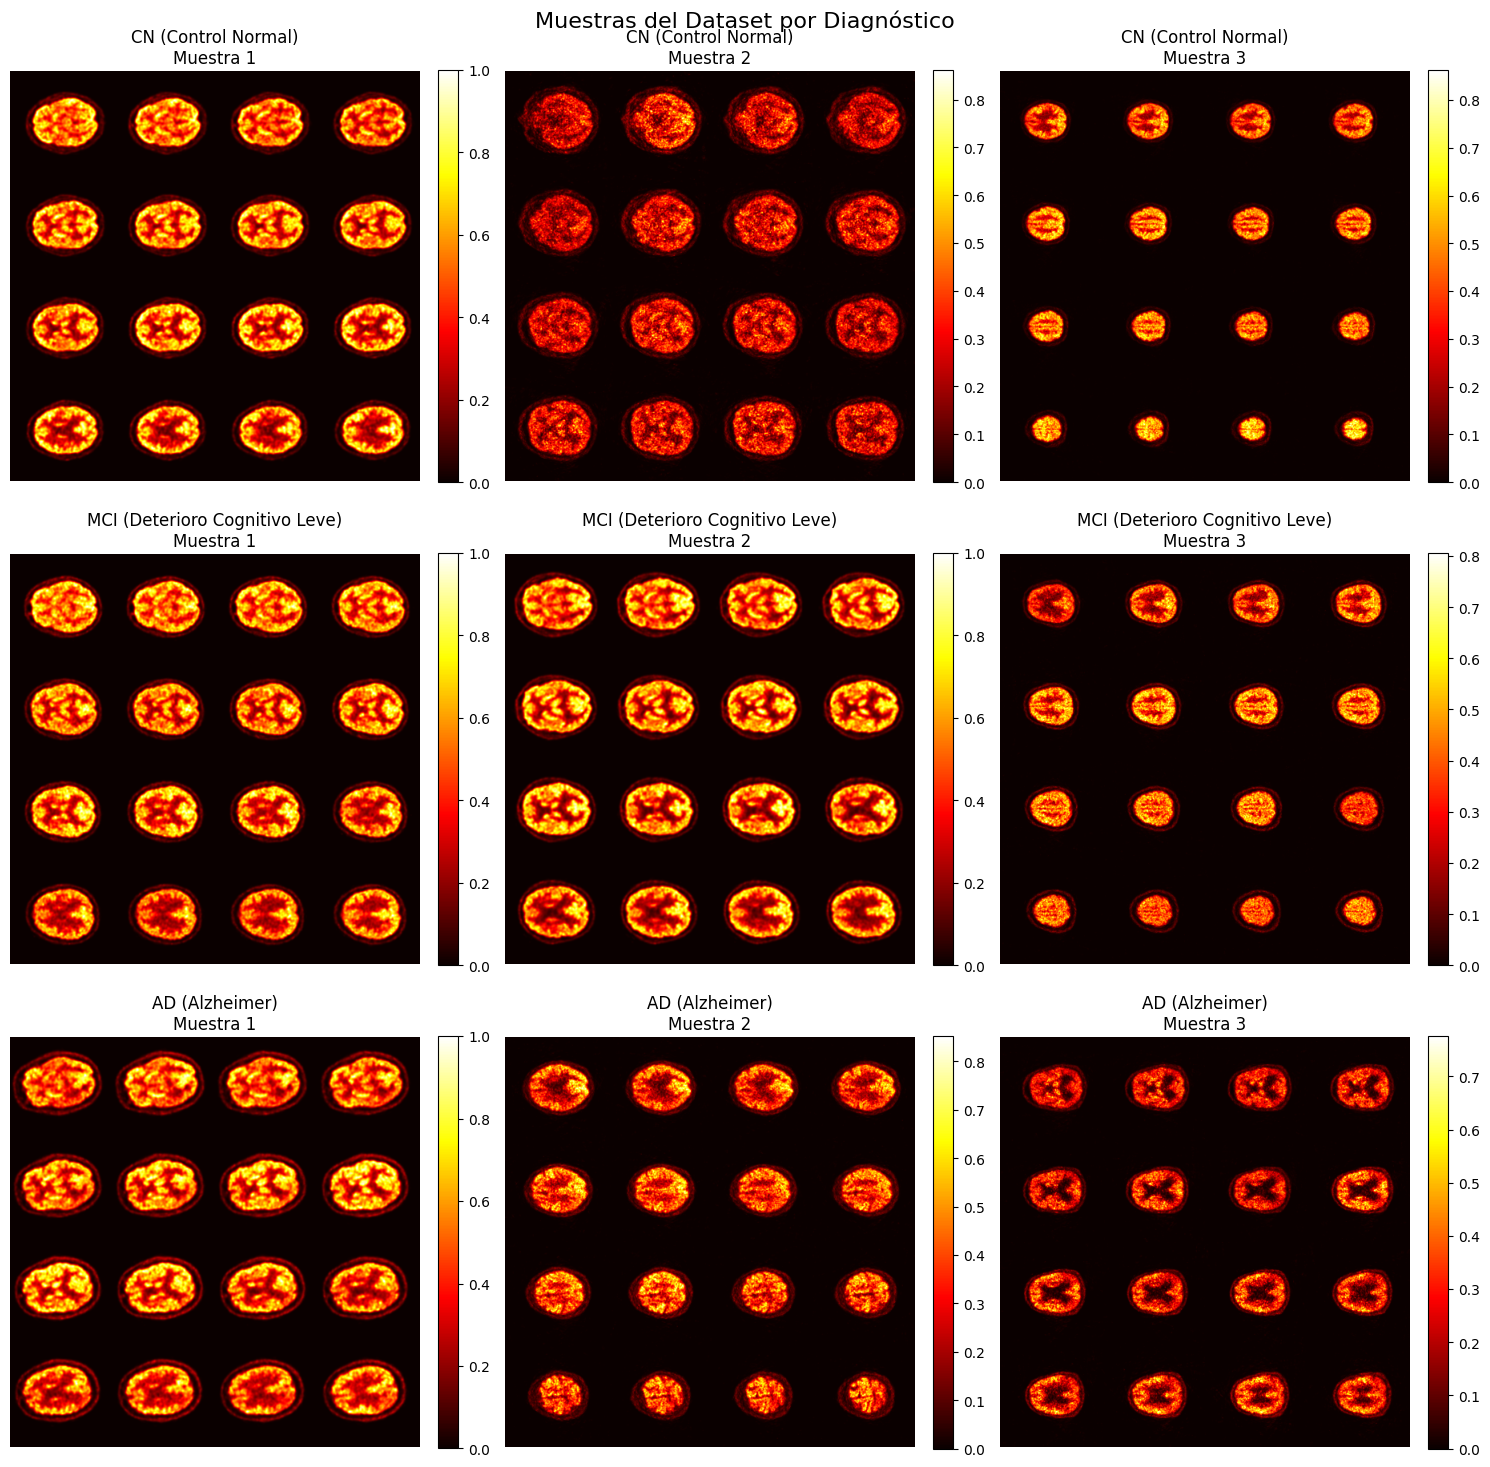

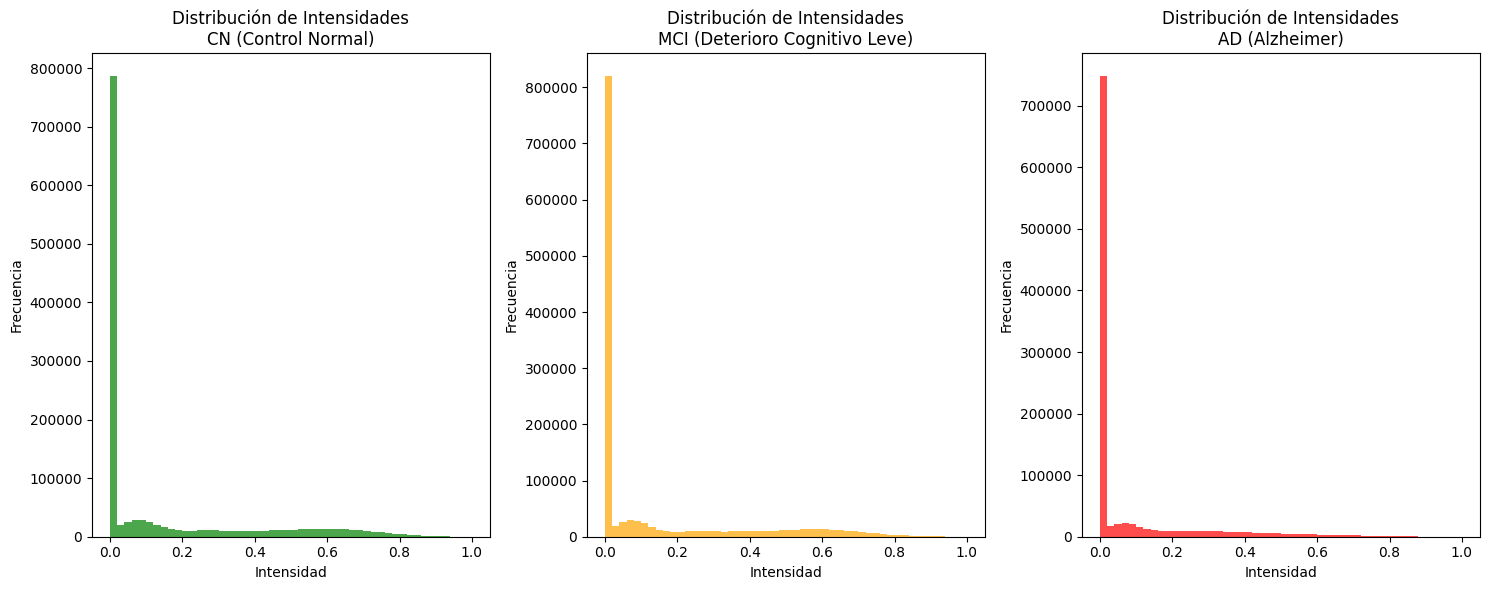

In [5]:
# Visualizar algunas muestras del dataset
if "dataset" in locals() and len(dataset.samples) > 0:
    # Definir una función para mapear etiquetas a diagnósticos
    def label_to_diagnosis(label):
        mapping = {
            0: "CN (Control Normal)",
            1: "MCI (Deterioro Cognitivo Leve)",
            2: "AD (Alzheimer)",
        }
        return mapping.get(label, f"Desconocido ({label})")

    # Visualizar información de distribución de clases
    labels = [label for _, label in dataset.samples]
    unique_labels, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(10, 6))
    plt.bar(
        [label_to_diagnosis(label) for label in unique_labels],
        counts,
        color=["green", "orange", "red"],
    )
    plt.title("Distribución de Clases en el Dataset")
    plt.ylabel("Número de muestras")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    # Visualizar múltiples muestras para cada clase
    samples_per_class = 3
    rows = len(unique_labels)
    cols = samples_per_class

    plt.figure(figsize=(15, 5 * rows))

    for i, label_value in enumerate(unique_labels):
        # Encontrar índices de muestras con esta etiqueta
        indices = [idx for idx, (_, label) in enumerate(dataset.samples) if label == label_value]

        # Seleccionar algunos índices aleatorios
        if len(indices) >= samples_per_class:
            selected_indices = np.random.choice(indices, samples_per_class, replace=False)
        else:
            selected_indices = indices

        # Mostrar las muestras seleccionadas
        for j, idx in enumerate(selected_indices):
            # Obtener la imagen y etiqueta directamente de samples para evitar __getitem__
            img_data, label = dataset.samples[idx]

            img = np.array(img_data, dtype=np.float32)

            plt.subplot(rows, cols, i * cols + j + 1)

            # Visualizar la imagen con colormap apropiado para PET
            plt.imshow(img, cmap="hot")  # 'hot' es común para imágenes PET

            # Añadir una barra de color para referencia de intensidad
            plt.colorbar(fraction=0.046, pad=0.04)

            plt.title(f"{label_to_diagnosis(label)}\nMuestra {j + 1}")
            plt.axis("off")

    plt.tight_layout()
    plt.suptitle("Muestras del Dataset por Diagnóstico", fontsize=16)
    plt.subplots_adjust(top=0.95)
    plt.show()

    # Análisis estadístico de intensidades
    plt.figure(figsize=(15, 6))

    # Mostrar histograma de intensidades por clase
    for i, label_value in enumerate(unique_labels):
        # Encontrar muestras con esta etiqueta
        indices = [idx for idx, (_, label) in enumerate(dataset.samples) if label == label_value]

        # Obtener datos de intensidad
        all_intensities = []
        for idx in indices[:5]:  # Limitar a 5 muestras por clase para evitar sobrecarga
            try:
                # Obtener imagen directamente de samples
                img_data, _ = dataset.samples[idx]

                if isinstance(img_data, torch.Tensor):
                    img_data = img_data.squeeze().cpu()

                img_array = np.array(img_data, dtype=np.float32)

                all_intensities.extend(img_array.flatten())
            except Exception as e:
                print(f"Error al procesar intensidades de la muestra {idx}: {e}")
                continue

        if all_intensities:
            # Crear histograma
            plt.subplot(1, len(unique_labels), i + 1)
            plt.hist(
                all_intensities,
                bins=50,
                alpha=0.7,
                color="green" if label_value == 0 else "orange" if label_value == 1 else "red",
            )
            plt.title(f"Distribución de Intensidades\n{label_to_diagnosis(label_value)}")
            plt.xlabel("Intensidad")
            plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()
else:
    print("No hay muestras para visualizar.")

In [15]:
# Probar la creación y uso de DataLoader
if "dataset" in locals() and len(dataset) > 0:
    try:
        # Definición para convertir etiqueta a diagnóstico
        def get_diagnosis(label):
            mapping = {
                0: "CN (Control Normal)",
                1: "MCI (Deterioro Cognitivo Leve)",
                2: "AD (Alzheimer)",
            }
            return mapping.get(label, f"Desconocido ({label})")

        # Dividir el dataset en entrenamiento/validación
        total_size = len(dataset)
        train_size = int(0.8 * total_size)
        val_size = total_size - train_size

        # Usar random_split para dividir correctamente
        from torch.utils.data import random_split

        train_dataset, val_dataset = random_split(
            dataset,
            [train_size, val_size],
            generator=torch.Generator().manual_seed(42),  # Semilla para reproducibilidad
        )

        print(
            f"Dataset dividido en: {len(train_dataset)} muestras de entrenamiento y {len(val_dataset)} de validación"
        )

        # Crear DataLoaders
        batch_size = 4  # Aumentar para ver más muestras por lote

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,  # En notebook, usar 0 workers para evitar problemas
            pin_memory=torch.cuda.is_available(),  # Optimizar si hay GPU
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        print("\nDataLoaders creados:")
        print(f"- Train: {len(train_loader)} lotes con batch_size={batch_size}")
        print(f"- Validación: {len(val_loader)} lotes con batch_size={batch_size}")

        # Obtener y visualizar un lote de entrenamiento
        iterator = iter(train_loader)
        batch_imgs, batch_labels = next(iterator)

        print(f"\nForma del lote de imágenes: {batch_imgs.shape}")
        print(f"Tipo de datos: {batch_imgs.dtype}")
        print(f"Rango de valores: [{batch_imgs.min().item():.4f}, {batch_imgs.max().item():.4f}]")
        print(f"Forma del lote de etiquetas: {batch_labels.shape}")
        print(f"Etiquetas en el lote: {batch_labels.tolist()}")
        print(f"Diagnósticos: {[get_diagnosis(label) for label in batch_labels.tolist()]}")

        # Visualizar el lote de entrenamiento
        plt.figure(figsize=(15, 5))
        plt.suptitle("Lote de Entrenamiento (Train Batch)", fontsize=16)

        for i in range(batch_size):
            if i < len(batch_imgs):
                img = batch_imgs[i].squeeze().numpy()
                label = batch_labels[i].item()
                diagnosis = get_diagnosis(label)

                plt.subplot(1, batch_size, i + 1)
                plt.imshow(img, cmap="hot")
                plt.colorbar(fraction=0.046, pad=0.04)
                plt.title(f"{diagnosis}")
                plt.axis("off")

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()

        # Comprobar iteración completa sobre el DataLoader
        print("\nRecorriendo todo el DataLoader de entrenamiento:")
        class_counts = {0: 0, 1: 0, 2: 0}

        for batch_idx, (imgs, labels) in enumerate(train_loader):
            # Contar etiquetas en este lote
            for label in labels.tolist():
                class_counts[label] = class_counts.get(label, 0) + 1

            # Mostrar progreso cada 5 lotes
            if batch_idx % 5 == 0 or batch_idx == len(train_loader) - 1:
                print(
                    f"  Lote {batch_idx + 1}/{len(train_loader)}, "
                    f"formas: imgs={imgs.shape}, labels={labels.shape}"
                )

        print("\nDistribución de clases en el conjunto de entrenamiento:")
        total = sum(class_counts.values())
        for label, count in class_counts.items():
            print(f"  - {get_diagnosis(label)}: {count} muestras ({count / total * 100:.1f}%)")

    except Exception as e:
        print(f"Error al crear o utilizar el DataLoader: {e}")
        import traceback

        traceback.print_exc()
else:
    print("No hay suficientes muestras para crear un DataLoader.")

No hay suficientes muestras para crear un DataLoader.


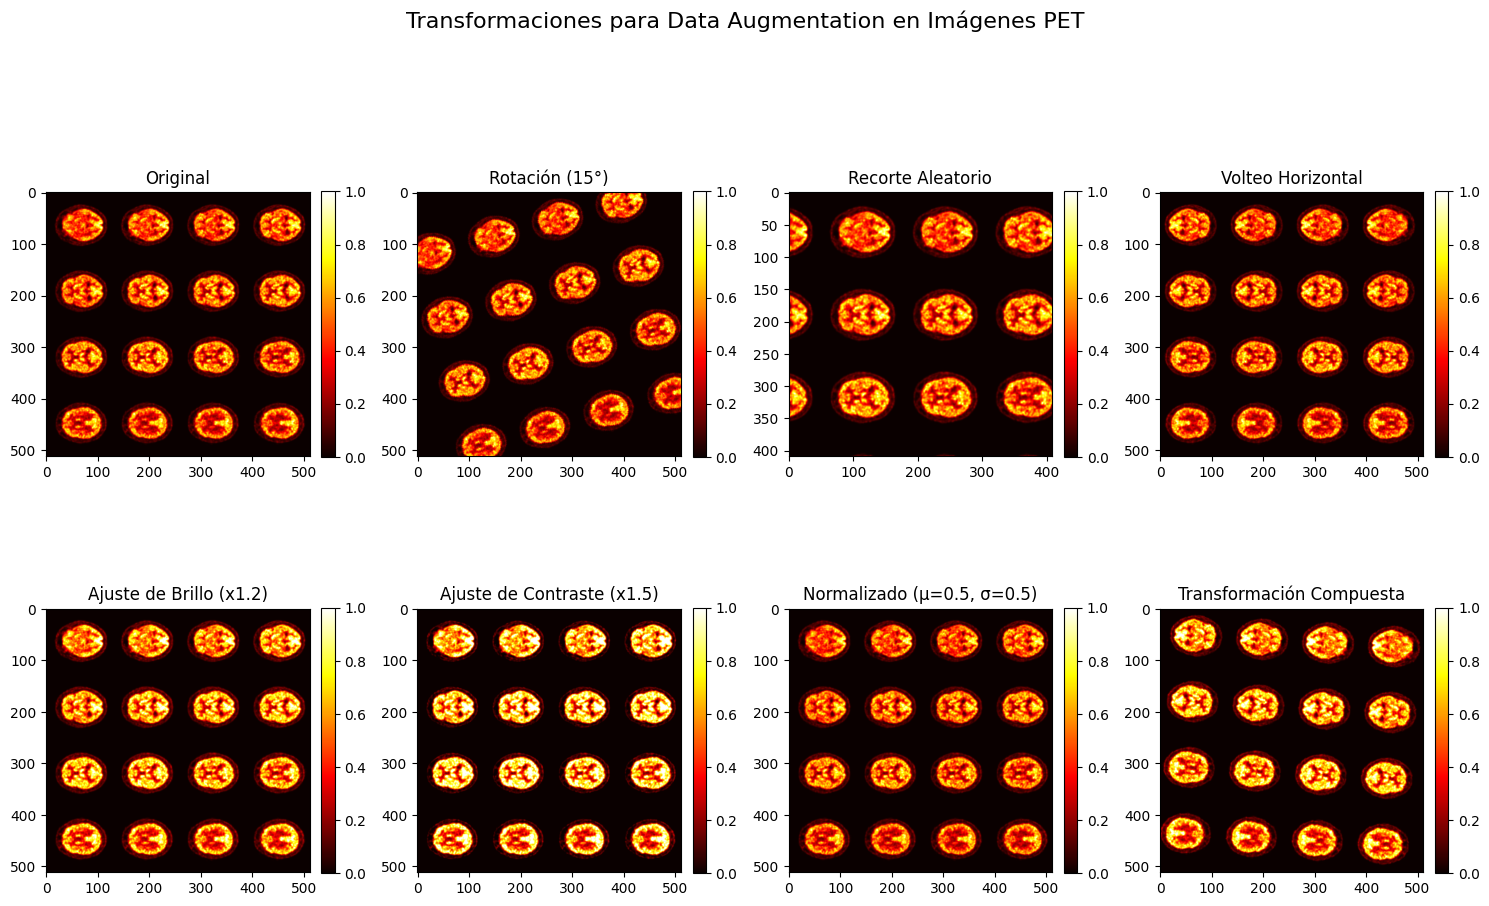

In [7]:
# Probar transformaciones para data augmentation en imágenes PET
if "dataset" in locals() and len(dataset) > 0:
    try:
        import torchvision.transforms.functional as TF
        from torchvision import transforms

        # Seleccionar una imagen de muestra
        img, label = dataset[0]

        # Si no es un tensor, convertirlo
        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img).float().unsqueeze(0)  # Añadir canal

        # Mostrar imagen original y transformaciones
        plt.figure(figsize=(15, 10))

        # Imagen original
        plt.subplot(2, 4, 1)
        plt.imshow(img.squeeze().numpy(), cmap="hot")
        plt.title("Original")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Rotación
        plt.subplot(2, 4, 2)
        rotated = TF.rotate(img, angle=15)
        plt.imshow(rotated.squeeze().numpy(), cmap="hot")
        plt.title("Rotación (15°)")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Recorte aleatorio
        plt.subplot(2, 4, 3)
        h, w = img.shape[-2:]
        crop_h, crop_w = int(h * 0.8), int(w * 0.8)
        i, j, h, w = transforms.RandomCrop.get_params(img, (crop_h, crop_w))
        cropped = TF.crop(img, i, j, h, w)
        plt.imshow(cropped.squeeze().numpy(), cmap="hot")
        plt.title("Recorte Aleatorio")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Volteo horizontal
        plt.subplot(2, 4, 4)
        flipped = TF.hflip(img)
        plt.imshow(flipped.squeeze().numpy(), cmap="hot")
        plt.title("Volteo Horizontal")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Cambio de brillo
        plt.subplot(2, 4, 5)
        brightness = TF.adjust_brightness(img, brightness_factor=1.2)
        plt.imshow(brightness.squeeze().numpy(), cmap="hot")
        plt.title("Ajuste de Brillo (x1.2)")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Cambio de contraste
        plt.subplot(2, 4, 6)
        contrast = TF.adjust_contrast(img, contrast_factor=1.5)
        plt.imshow(contrast.squeeze().numpy(), cmap="hot")
        plt.title("Ajuste de Contraste (x1.5)")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Normalización (torchvision)
        plt.subplot(2, 4, 7)
        normalized = TF.normalize(img, mean=[0.5], std=[0.5])  # a [-1, 1]
        # Rescalar para visualización
        normalized_viz = (normalized + 1) / 2  # Volver a [0, 1]
        plt.imshow(normalized_viz.squeeze().numpy(), cmap="hot")
        plt.title("Normalizado (µ=0.5, σ=0.5)")
        plt.colorbar(fraction=0.046, pad=0.04)

        # Entrenamiento combinado
        plt.subplot(2, 4, 8)
        # Crear una transformación compuesta como se usaría en entrenamiento
        transform = transforms.Compose(
            [
                transforms.RandomRotation(15),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.Normalize([0.5], [0.5]),
            ]
        )

        # Aplicar transformación compuesta
        # Necesitamos asegurar dimensionalidad correcta (C,H,W)
        transformed = transform(img)
        # Rescalar para visualización
        transformed_viz = (transformed + 1) / 2  # Volver a [0, 1]
        plt.imshow(transformed_viz.squeeze().numpy(), cmap="hot")
        plt.title("Transformación Compuesta")
        plt.colorbar(fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.suptitle("Transformaciones para Data Augmentation en Imágenes PET", fontsize=16)
        plt.subplots_adjust(top=0.9)
        plt.show()

    except Exception as e:
        print(f"Error al aplicar transformaciones: {e}")
        import traceback

        traceback.print_exc()
else:
    print("No hay muestras para probar transformaciones.")

# Model

In [5]:
# Entrenar un modelo ResNet-18 2D utilizando nuestro dataset

# Importar librerías necesarias
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import auc, roc_curve
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# Asegurar que podemos importar desde el directorio raíz
sys.path.append("/Users/nacho/Desktop/code/PET_2025")

# Importar funciones para cargar el modelo ResNet-18 2D
from models.resnet18.resnet18_2d import get_resnet18_2d

# Configuración del entrenamiento
config = {
    "num_classes": 2,  # Binario: CN vs AD
    "pretrained": True,  # Cargar pesos preentrenados
    "learning_rate": 0.0001,
    "batch_size": 16,
    "epochs": 10,
    "device": torch.device(
        "cuda"
        if torch.cuda.is_available()
        else ("mps" if torch.backends.mps.is_available() else "cpu")
    ),
}

print(f"Utilizando dispositivo: {config['device']}")

# Crear dataset y dividirlo en train/val/test


# Definir las rutas a los archivos CSV
train_csv = "/Users/nacho/Desktop/code/PET_2025/data/metadata/adni_train.csv"
val_csv = "/Users/nacho/Desktop/code/PET_2025/data/metadata/adni_val.csv"
test_csv = "/Users/nacho/Desktop/code/PET_2025/data/metadata/adni_test.csv"
data_dir = "/Volumes/Seagate/new_downloads/PET/converted_niftis"

# Crear los datasets
train_dataset = PETDataset(
    data_dir=data_dir,
    csv_path=train_csv,
    slice_selection="uniform",
    num_slices=16,
    mode="train",
    # limit=80
)

val_dataset = PETDataset(
    data_dir=data_dir,
    csv_path=val_csv,
    slice_selection="uniform",
    num_slices=16,
    mode="val",
    # limit=10
)

test_dataset = PETDataset(
    data_dir=data_dir,
    csv_path=test_csv,
    slice_selection="uniform",
    num_slices=16,
    mode="test",
    # limit=10
)

print(
    f"Tamaños de los datasets:\n- Train: {len(train_dataset)}\n- Val: {len(val_dataset)}\n- Test: {len(test_dataset)}"
)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

Utilizando dispositivo: mps
CSV cargado. Filas: 892
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['CN', 'MCI', 'AD']


Cargando dataset:   0%|          | 1/892 [00:02<37:27,  2.52s/it]

Cargado volumen de forma: (224, 224, 81, 6)


Cargando dataset: 100%|██████████| 892/892 [13:09<00:00,  1.13it/s]


Total de muestras cargadas: 892 de 892 sujetos

Distribución de clases:
  - CN: 272 muestras (30.5%)
  - MCI: 439 muestras (49.2%)
  - AD: 181 muestras (20.3%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'AD', 'CN']


...

Total de muestras cargadas: 112 de 112 sujetos

Distribución de clases:
  - CN: 35 muestras (31.2%)
  - MCI: 55 muestras (49.1%)
  - AD: 22 muestras (19.6%)
CSV cargado. Filas: 112
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   1%|          | 1/112 [00:00<00:29,  3.71it/s]

Cargado volumen de forma: (128, 128, 47, 6)


Cargando dataset: 100%|██████████| 112/112 [01:05<00:00,  1.71it/s]

Total de muestras cargadas: 112 de 112 sujetos

Distribución de clases:
  - CN: 34 muestras (30.4%)
  - MCI: 55 muestras (49.1%)
  - AD: 23 muestras (20.5%)
Tamaños de los datasets:
- Train: 892
- Val: 112
- Test: 112


In [28]:
config_path = Path("/Users/nacho/Desktop/code/PET_2025/configs/resnet18_2d_adni_cnmciad.yaml")
config = load_config(config_path)

In [33]:
config["device"] = torch.device(
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print(f"Configuración cargada: {config}")

Configuración cargada: {'experiment': {'base_dir': './experiments', 'name': 'baseline'}, 'model': {'name': 'resnet18', 'dimension': '2d', 'pretrained': True}, 'data': {'dataset_name': 'ADNI', 'classes': 'CN_MCI_AD', 'dimension': '2d', 'data_dir': '/Volumes/Seagate/new_downloads/PET/converted_niftis', 'train_csv': './data/metadata/adni_train.csv', 'val_csv': './data/metadata/adni_val.csv', 'test_csv': './data/metadata/adni_test.csv', 'num_workers': 4, 'slice_selection': 'uniform', 'num_slices': 16, 'augmentation': {'enabled': True, 'rotate_degrees': 10, 'scale_range': [0.9, 1.1], 'translate': [0.1, 0.1]}}, 'training': {'epochs': 100, 'early_stopping_patience': 10, 'optimizer': {'name': 'adam', 'lr': 0.0001, 'weight_decay': 0.0001}, 'scheduler': {'name': 'reduce_on_plateau', 'mode': 'max', 'factor': 0.5, 'patience': 5}, 'loss': {'name': 'cross_entropy', 'weighted': False, 'class_weights': [1.0, 1.0]}}, 'device': device(type='mps')}


In [35]:
# {'experiment': {'base_dir': './experiments', 'name': 'baseline'}, 'model': {'name': 'resnet18', 'dimension': '2d', 'pretrained': True}, 'data': {'dataset_name': 'ADNI', 'classes': 'CN_MCI_AD', 'dimension': '2d', 'data_dir': '/Volumes/Seagate/new_downloads/PET/converted_niftis', 'train_csv': './data/metadata/adni_train.csv', 'val_csv': './data/metadata/adni_val.csv', 'test_csv': './data/metadata/adni_test.csv', 'num_workers': 4, 'slice_selection': 'uniform', 'num_slices': 16, 'augmentation': {'enabled': True, 'rotate_degrees': 10, 'scale_range': [0.9, 1.1], 'translate': [0.1, 0.1]}}, 'training': {'epochs': 100, 'early_stopping_patience': 10, 'optimizer': {'name': 'adam', 'lr': 0.0001, 'weight_decay': 0.0001}, 'scheduler': {'name': 'reduce_on_plateau', 'mode': 'max', 'factor': 0.5, 'patience': 5}, 'loss': {'name': 'cross_entropy', 'weighted': False, 'class_weights': [1.0, 1.0]}}, 'device': device(type='mps')}
config["experiment"] = {"base_dir": "./experiments", "name": "baseline_nb"}
config

{'experiment': {'base_dir': './experiments', 'name': 'baseline_nb'},
 'model': {'name': 'resnet18', 'dimension': '2d', 'pretrained': True},
 'data': {'dataset_name': 'ADNI',
  'classes': 'CN_MCI_AD',
  'dimension': '2d',
  'data_dir': '/Volumes/Seagate/new_downloads/PET/converted_niftis',
  'train_csv': './data/metadata/adni_train.csv',
  'val_csv': './data/metadata/adni_val.csv',
  'test_csv': './data/metadata/adni_test.csv',
  'num_workers': 4,
  'slice_selection': 'uniform',
  'num_slices': 16,
  'augmentation': {'enabled': True,
   'rotate_degrees': 10,
   'scale_range': [0.9, 1.1],
   'translate': [0.1, 0.1]}},
 'training': {'epochs': 100,
  'early_stopping_patience': 10,
  'optimizer': {'name': 'adam', 'lr': 0.0001, 'weight_decay': 0.0001},
  'scheduler': {'name': 'reduce_on_plateau',
   'mode': 'max',
   'factor': 0.5,
   'patience': 5},
  'loss': {'name': 'cross_entropy',
   'weighted': False,
   'class_weights': [1.0, 1.0]}},
 'device': device(type='mps')}

MovieWriter imagemagick unavailable; using Pillow instead.


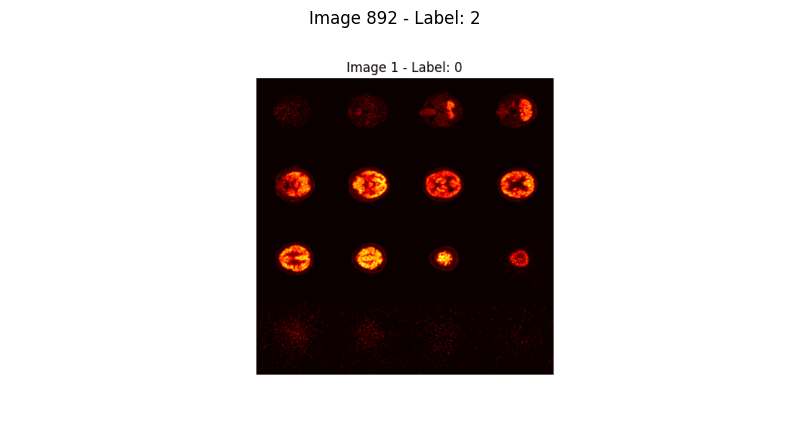

In [14]:
# With Matplotlib plot one by one the images of the train dataset
# Animated
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


def animate_images(train_loader, interval=500):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")
    images = []
    labels = []

    iterator = iter(train_loader)
    for batch_imgs, batch_labels in iterator:
        for img, label in zip(batch_imgs, batch_labels, strict=False):
            images.append(img.numpy())
            labels.append(label.item())

    images = np.array(images)
    labels = np.array(labels)

    def update(frame):
        ax.clear()
        ax.imshow(images[frame].squeeze(), cmap="hot")
        ax.set_title(f"Image {frame + 1} - Label: {labels[frame]}")
        ax.axis("off")

    ani = FuncAnimation(fig, update, frames=len(images), interval=interval)

    # save the animation as a gif
    ani.save("animated_images.gif", writer="imagemagick", fps=2)

    # plot the animation
    gif = plt.imread("animated_images.gif")
    plt.imshow(gif)
    plt.axis("off")


# Llamar a la función de animación
animate_images(train_loader, interval=500)

In [16]:
images = []
labels = []

iterator = iter(train_loader)
for batch_imgs, batch_labels in iterator:
    for img, label in zip(batch_imgs, batch_labels, strict=False):
        images.append(img.numpy())
        labels.append(label.item())

images = np.array(images)
labels = np.array(labels)

In [18]:
images.mean(), images.std(), images.min(), images.max()

(0.09350985, 0.1718562, 0.0, 1.0)

In [19]:
images = []
labels = []

iterator = iter(val_loader)
for batch_imgs, batch_labels in iterator:
    for img, label in zip(batch_imgs, batch_labels, strict=False):
        images.append(img.numpy())
        labels.append(label.item())

images = np.array(images)
labels = np.array(labels)

images.mean(), images.std(), images.min(), images.max()

(0.084401235, 0.16741161, 0.0, 1.0)

In [ ]:
images = []
labels = []

iterator = iter(test_loader)
for batch_imgs, batch_labels in iterator:
    for img, label in zip(batch_imgs, batch_labels, strict=False):
        images.append(img.numpy())
        labels.append(label.item())

images = np.array(images)
labels = np.array(labels)
C
images.mean(), images.std(), images.min(), images.max()

(0.09210562, 0.17105858, 0.0, 1.0)

In [12]:
batch_imgs.shape

torch.Size([16, 1, 512, 512])

In [40]:
# Crear modelo ResNet-18 2D
model = get_resnet18_2d(config)
model.to(config["device"])

# Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=config["training"]["optimizer"]["lr"],
    weight_decay=config["training"]["optimizer"]["weight_decay"],
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, verbose=True
)


# Función para entrenar una época
def train_epoch(model, loader, criterion, optimizer, scheduler, device, epoch_iterator=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Usar tqdm para mostrar una barra de progreso
    with tqdm(loader, desc="Entrenando", unit="batch") as pbar:
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # Asegurar que las imágenes tienen la dimensionalidad correcta [B, C, H, W]
            if images.dim() == 3:  # [B, H, W]
                images = images.unsqueeze(1)  # Añadir canal [B, 1, H, W]

            # Reiniciar gradientes
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass y optimización
            loss.backward()
            scheduler.step(loss)  # Actualizar scheduler antes de optimizar
            optimizer.step()

            # Estadísticas
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Actualizar barra de progreso
            epoch_iterator.set_postfix({"loss": loss.item(), "acc": 100.0 * correct / total})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


# Función para validar el modelo
def validate(model, loader, criterion, device, pbar=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Asegurar que las imágenes tienen la dimensionalidad correcta
            if images.dim() == 3:  # [B, H, W]
                images = images.unsqueeze(1)  # Añadir canal [B, 1, H, W]

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Obtener probabilidades usando softmax
            probs = nn.functional.softmax(outputs, dim=1)

            # Guardar etiquetas y probabilidades para ROC-AUC
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy()[:, 1])  # Probabilidad de la clase positiva (AD)

            # Estadísticas
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    # Calcular métricas
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = 100.0 * correct / total

    # Calcular ROC-AUC si hay al menos una muestra de cada clase
    roc_auc = 0
    # if len(set(all_labels)) > 1 and len(all_labels) > 1:
    # roc_auc = roc_auc_score(all_labels, all_probs)

    if pbar is not None:
        pbar.set_description("Validando")
        pbar.set_postfix({"val_loss": epoch_loss, "val_acc": epoch_acc, "val_auc": roc_auc})

    return epoch_loss, epoch_acc, roc_auc, all_labels, all_probs


# Listas para almacenar métricas durante el entrenamiento
train_losses = []
train_accs = []
val_losses = []
val_accs = []
val_aucs = []

# Entrenamiento del modelo
print("\nIniciando entrenamiento de ResNet-18 2D...")
best_val_acc = 0.0
best_val_auc = 0.0

# for epoch in range(config["epochs"]):
epoch_iterator = tqdm(range(config["training"]["epochs"]), desc="Épocas")
for _epoch in epoch_iterator:
    # print(f"\nÉpoca {epoch+1}/{config['epochs']}")

    # Entrenamiento
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, config["device"], epoch_iterator
    )
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validación
    val_loss, val_acc, val_auc, _, _ = validate(
        model, val_loader, criterion, config["device"], epoch_iterator
    )
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print(
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f}"
    )

    # Guardar el mejor modelo según precisión
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # torch.save(model.state_dict(), "/Users/nacho/Desktop/code/PET_2025/models/resnet18/2d/best_model_acc.pth")
        epoch_iterator.set_postfix({"best_val_acc": best_val_acc, "best_val_auc": best_val_auc})

    # Guardar el mejor modelo según AUC
    if val_auc > best_val_auc and val_auc > 0:
        best_val_auc = val_auc
        # torch.save(model.state_dict(), "/Users/nacho/Desktop/code/PET_2025/models/resnet18/2d/best_model_auc.pth")
        epoch_iterator.set_postfix({"best_val_acc": best_val_acc, "best_val_auc": best_val_auc})

# Evaluar en el conjunto de prueba
print("\nEvaluando en conjunto de prueba...")
# Cargar el mejor modelo (por AUC si es válido, de lo contrario por precisión)
best_model_path = (
    "/Users/nacho/Desktop/code/PET_2025/models/resnet18/2d/best_model_auc.pth"
    if best_val_auc > 0
    else "/Users/nacho/Desktop/code/PET_2025/models/resnet18/2d/best_model_acc.pth"
)
model.load_state_dict(torch.load(best_model_path))
test_loss, test_acc, test_auc, test_labels, test_probs = validate(
    model, test_loader, criterion, config["device"]
)
print(f"Prueba - Loss: {test_loss:.4f}, Accuracy: {test_acc:.2f}%, AUC: {test_auc:.4f}")

# Visualizar las métricas de entrenamiento
plt.figure(figsize=(15, 10))

# Gráfico de pérdida
plt.subplot(2, 2, 1)
plt.plot(train_losses, label="Entrenamiento")
plt.plot(val_losses, label="Validación")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()

# Gráfico de precisión
plt.subplot(2, 2, 2)
plt.plot(train_accs, label="Entrenamiento")
plt.plot(val_accs, label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Precisión (%)")
plt.legend()

# Gráfico de AUC
plt.subplot(2, 2, 3)
plt.plot(val_aucs, label="Validación")
plt.title("ROC-AUC durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("ROC-AUC")
plt.legend()

# Gráfico de curva ROC para el conjunto de prueba
if len(set(test_labels)) > 1 and len(test_labels) > 1:
    plt.subplot(2, 2, 4)
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.title("Curva ROC - Conjunto de Prueba")
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n¡Entrenamiento completado!")
print(f"Mejor precisión de validación: {best_val_acc:.2f}%")
print(f"Mejor ROC-AUC de validación: {best_val_auc:.4f}")
print(f"Precisión en conjunto de prueba: {test_acc:.2f}%")
print(f"ROC-AUC en conjunto de prueba: {test_auc:.4f}")


Iniciando entrenamiento de ResNet-18 2D...


Validando:   1%|          | 1/100 [01:58<3:15:42, 118.61s/it, best_val_acc=49.1, best_val_auc=0]

Train Loss: 0.5406, Train Acc: 47.42% | Val Loss: 0.5342, Val Acc: 49.11%, Val AUC: 0.0000


Validando:   2%|▏         | 2/100 [03:41<2:58:28, 109.27s/it, val_loss=0.546, val_acc=47.3, val_auc=0]

Train Loss: 0.5126, Train Acc: 50.34% | Val Loss: 0.5463, Val Acc: 47.32%, Val AUC: 0.0000


...

Train Loss: 0.5097, Train Acc: 50.78% | Val Loss: 0.5471, Val Acc: 49.11%, Val AUC: 0.0000


Validando:  42%|████▏     | 42/100 [3:59:53<51:28:59, 3195.51s/it, val_loss=0.546, val_acc=49.1, val_auc=0]

Train Loss: 0.5130, Train Acc: 51.01% | Val Loss: 0.5463, Val Acc: 49.11%, Val AUC: 0.0000


Entrenando:  25%|██▌       | 14/56 [00:35<01:47,  2.56s/batch]/it, loss=0.641, acc=44.6]                   

: 

In [ ]:
# Visualización detallada de curvas ROC y análisis de métricas

try:
    # Cargar el mejor modelo nuevamente para asegurar que tenemos el correcto
    if "model" in locals() and "test_loader" in locals() and "config" in locals():
        print("Generando visualización detallada de la curva ROC...")

        # Evaluar modelo en conjunto de prueba
        model.eval()
        all_labels = []
        all_probs = []
        all_preds = []
        class_correct = [0] * config["num_classes"]
        class_total = [0] * config["num_classes"]

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(config["device"]), labels.to(config["device"])

                # Asegurar dimensionalidad correcta
                if images.dim() == 3:
                    images = images.unsqueeze(1)

                # Forward pass
                outputs = model(images)
                probs = nn.functional.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                # Guardar resultados
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy()[:, 1])  # Probabilidad de clase positiva
                all_preds.extend(preds.cpu().numpy())

                # Estadísticas por clase
                correct = preds.eq(labels)
                for i in range(len(labels)):
                    label = labels[i].item()
                    class_correct[label] += correct[i].item()
                    class_total[label] += 1

        # Calcular métricas por clase
        class_names = ["CN (Control Normal)", "AD (Alzheimer)"]
        print("\nPrecisión por clase:")
        for i in range(config["num_classes"]):
            if class_total[i] > 0:
                accuracy = 100 * class_correct[i] / class_total[i]
                print(f"- {class_names[i]}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})")

        # Calcular y mostrar matriz de confusión
        import seaborn as sns
        from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(10, 8))

        # Matriz de confusión
        plt.subplot(2, 2, 1)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names
        )
        plt.xlabel("Predicción")
        plt.ylabel("Valor Real")
        plt.title("Matriz de Confusión")

        # Curva ROC
        plt.subplot(2, 2, 2)
        fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], "k--", lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("Tasa de Falsos Positivos")
        plt.ylabel("Tasa de Verdaderos Positivos")
        plt.title("Curva ROC")
        plt.legend(loc="lower right")

        # Curva Precision-Recall
        plt.subplot(2, 2, 3)
        precision, recall, _ = precision_recall_curve(all_labels, all_probs)
        plt.plot(recall, precision, lw=2)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")

        # Histograma de probabilidades
        plt.subplot(2, 2, 4)
        for i, label in enumerate(set(all_labels)):
            mask = np.array(all_labels) == label
            plt.hist(np.array(all_probs)[mask], bins=20, alpha=0.5, label=class_names[int(label)])
        plt.xlabel("Probabilidad de clase AD")
        plt.ylabel("Frecuencia")
        plt.title("Distribución de Probabilidades por Clase")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Mostrar informe de clasificación
        print("\nInforme de clasificación:")
        print(classification_report(all_labels, all_preds, target_names=class_names))

        # Puntos óptimos en la curva ROC
        # Encontrar el punto óptimo en la curva ROC (máximo Youden's J statistic)
        j_scores = tpr - fpr
        best_threshold_idx = np.argmax(j_scores)
        best_threshold = thresholds[best_threshold_idx]
        best_tpr = tpr[best_threshold_idx]
        best_fpr = fpr[best_threshold_idx]

        print(f"\nUmbral óptimo: {best_threshold:.4f}")
        print(f"En este umbral: TPR = {best_tpr:.4f}, FPR = {best_fpr:.4f}")
        print(f"Índice de Youden (J = TPR - FPR): {j_scores[best_threshold_idx]:.4f}")

    else:
        print(
            "No se encontró el modelo o los datos de prueba. Ejecuta primero la celda de entrenamiento."
        )

except Exception as e:
    print(f"Error al generar visualización: {e}")
    import traceback

    traceback.print_exc()